# Demo: Renormalization Group Evolution (RGE)

This notebook demonstrates how to use `RGEsolver` to study the scale dependence of dark sector couplings and the scalar VEV in the dark $U(1)$ model.

**Pipeline step:** RGE is the first layer — all other modules (Veff, bounce solver, FOPT) call it internally to evaluate couplings at a given renormalization scale $\mu$.

**Modules used:** `src/RGE/RGEsolver.py`, `src/RGE/VeffFunc_RGE.py`

**Contents:**
1. Running of dark sector couplings $g_D^2$, $\lambda_S$, $m_S^2$ with $\mu$
2. Scale dependence of the scalar VEV $\langle\phi\rangle(\mu)$

In [2]:
%load_ext autoreload
%autoreload 2

%run startup.py

startup.py loaded: numpy, scipy, matplotlib, and all project modules are ready.
  Use new_figure() to create pre-formatted plots.


In [3]:
# Instantiate the RGE solver and the effective potential
rge_solver = rge.RGESolver()
veff_obj   = veff.VeffRGE(vt_table_path="VT_integralNumeric.dat")
solver_ht  = bs_ht.BounceSolverHighT(veff=veff_obj)

## 1. Running of dark sector couplings

Solve the one-loop RGE system from $\mu_0 = 1$ across 14 decades. The beta functions are defined in `RGEsolver.py`:
$$\beta_{g_D^2} = \frac{g_D^4}{24\pi^2}, \qquad \beta_{\lambda_S} = \frac{3g_D^4 - 6g_D^2\lambda_S + 10\lambda_S^2}{8\pi^2}, \qquad \beta_{m_S^2} = -m_S^2\frac{3g_D^2 - 4\lambda_S}{8\pi^2}$$

In [22]:
# === Initial conditions at mu0 = 1 ===
gD0       = 0.6
lambdaS0  = 0.0
ms0       = 1e-10
logT_span = (0, 10)   # log(mu) range: mu in [1, e^10]

# Integrate RGE once with dense output for smooth curves
sol = solve_ivp(
    rge_solver.RGEs_logMu,
    logT_span,
    [gD0**2, lambdaS0, ms0],
    dense_output=True,
    max_step=0.1
)

# Evaluate at 200 log-spaced scale values
mu_vals   = np.logspace(-10, 4, 200)
logmu_vals = np.log(mu_vals)
y_vals    = sol.sol(logmu_vals)          # shape: (3, 200)
gD2_vals, lambdaS_vals, mS_vals = y_vals

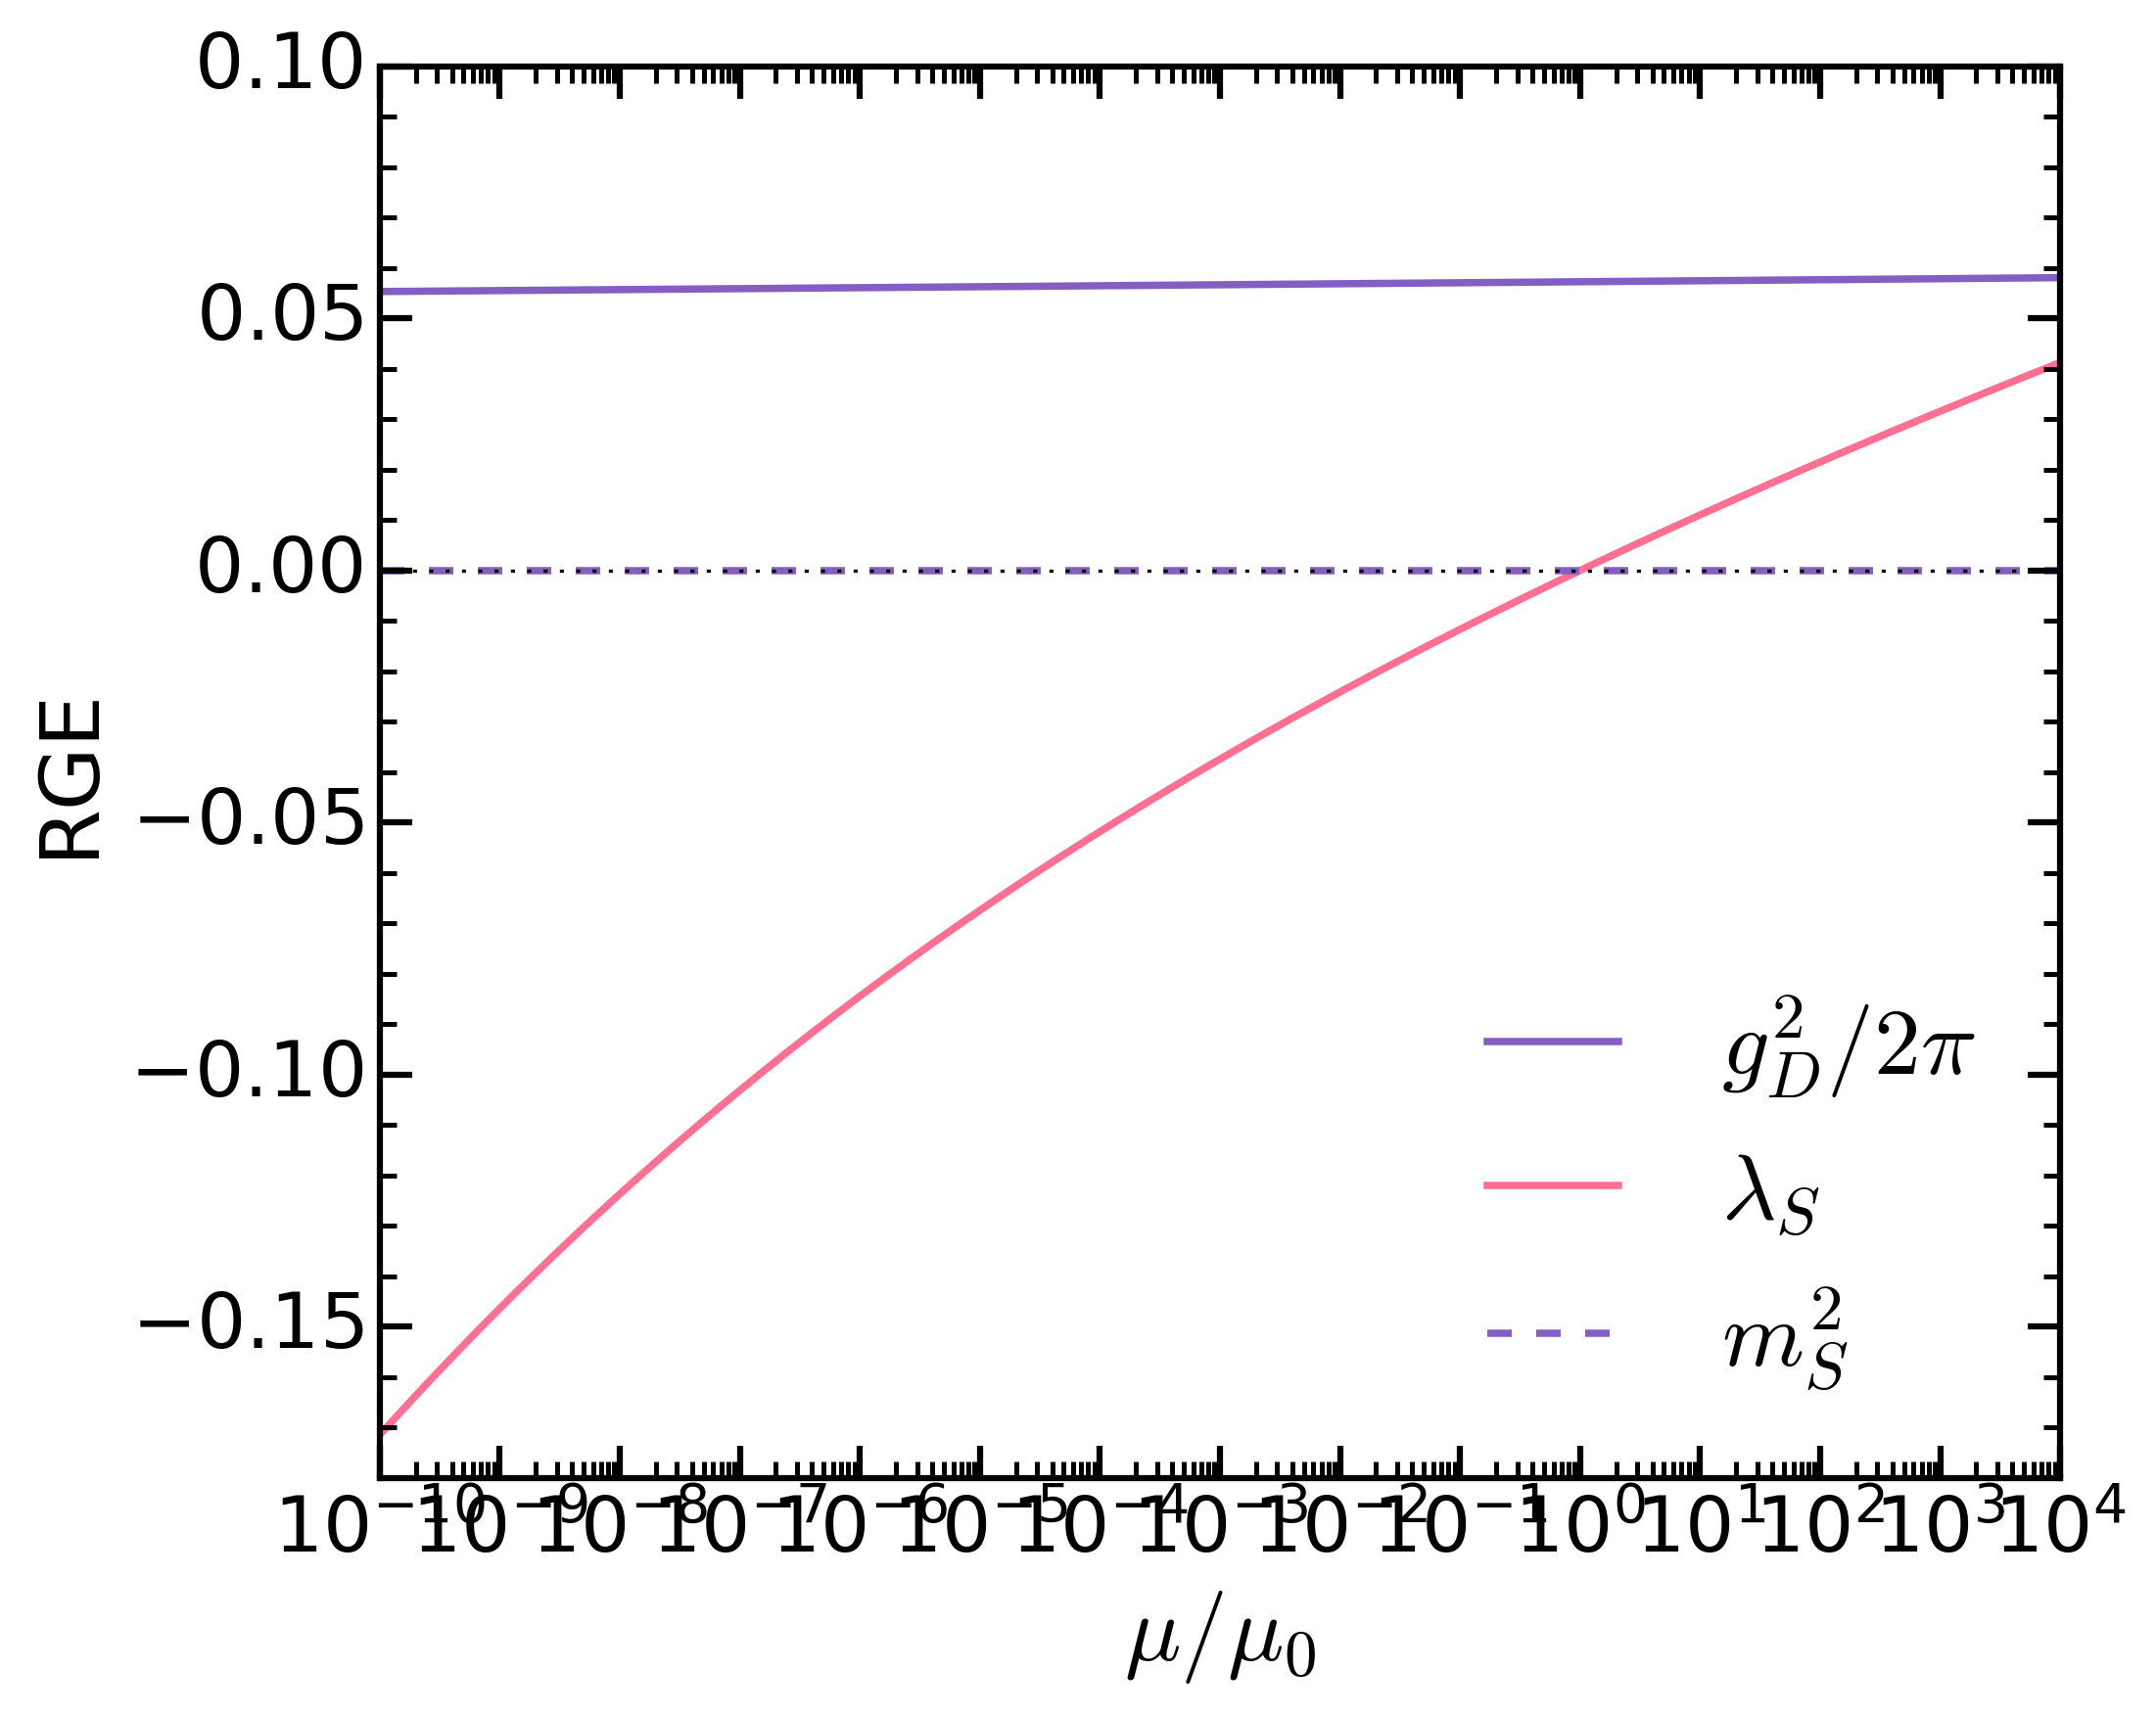

In [33]:
fig, ax = new_figure(figsize=(7.5, 6), dpi=300)
fig.patch.set_facecolor('white')

ax.plot(mu_vals, gD2_vals / (2 * np.pi), lw=1.8, color='#845ec2', label=r'$g_D^2 / 2\pi$')
ax.plot(mu_vals, lambdaS_vals,            lw=1.8, color='#ff6f91', label=r'$\lambda_S$')
ax.plot(mu_vals, mS_vals,                 lw=1.8, color='#845ec2', ls='--', label=r'$m_S^2$')

ps.apply_standard_formatting(
    ax,
    xlog=True, ylog=False,
    xlabel=r'$\mu/\mu_0$',
    ylabel=r'RGE',
    ylim=(-0.18, 0.1),
)
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.legend(loc='lower right', frameon=False, fontsize=23)
plt.tight_layout()

## 2. Scale dependence of the VEV

For each value of the initial coupling $g_D(\mu_0)$, run the RGE to scale $\mu$ and minimize $V_{\rm eff}^{\rm T=0}(\phi;\mu)$ to find the VEV $\langle\phi\rangle(\mu)$. The physical VEV must be $\mu$-independent; any residual dependence indicates higher-order corrections.

In [16]:
mu0      = 1.0
ls0, mS0 = 0.0, 0.0
gD0_list = [0.5, 0.6, 0.7, 0.8]
mu_sweep = np.logspace(-3, 3, 200)

results = {}
for gD0 in gD0_list:
    v_over_mu0 = []
    for mu in mu_sweep:
        gD_mu, _, _ = rge_solver.run_params(mu=mu, gD0=gD0, lambdaS0=ls0, mS0=mS0)
        v_mu = solver_ht.phi_min_Veff0(T=1, gD=gD_mu, scale=mu, ls0=ls0)
        v_over_mu0.append(v_mu / mu0)
    results[gD0] = np.array(v_over_mu0)

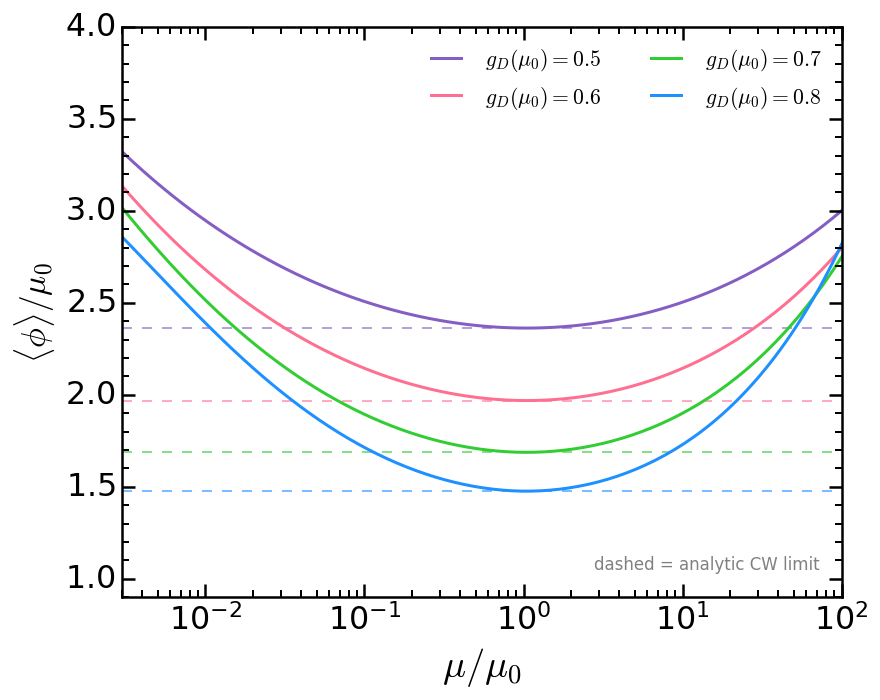

In [17]:
colors = ['#845ec2', '#ff6f91', 'limegreen', 'dodgerblue']

fig, ax = new_figure(figsize=(7.5, 6), dpi=120)
fig.patch.set_facecolor('white')

for (gD0, vals), c in zip(results.items(), colors):
    ax.plot(mu_sweep / mu0, vals, color=c, lw=1.8, label=fr'$g_D(\mu_0)={gD0}$')
    # Analytic asymptotic value at mu = mu0: v_CW = exp(1/6) * mu0 / gD0
    ax.axhline(np.exp(1/6) / gD0, color=c, ls='--', lw=1.0, alpha=0.7)

ps.apply_standard_formatting(
    ax,
    xlog=True, ylog=False,
    xlabel=r'$\mu/\mu_0$',
    ylabel=r'$\langle\phi\rangle / \mu_0$',
    ylim=(0.9, 4),
    xlim=(3e-3, 1e2),
)
ax.legend(loc='best', frameon=False, fontsize=13, ncol=2)
ax.text(0.97, 0.05, 'dashed = analytic CW limit', transform=ax.transAxes,
        ha='right', fontsize=10, color='gray')
plt.tight_layout()

In [9]:
# Values of g, lambda, ms, etc at T = 0.00001
T = 0.0001
gD0 = 0.6
ls0 = 0.0
ms0 = 0.0
gD_T, lambdaS_T, mS_T = rge_solver.run_params(mu=T, gD0=gD0, lambdaS0=ls0, mS0=ms0)
print("RGE values at T = 0.0001:")
print(f"gD={gD_T:.3f}, lambdaS={lambdaS_T:.3e}, mS^2={mS_T:.3e}")
print("------------------------------------")
print(f" gD={gD_T:.3f}, lambdaS={lambdaS_T:.3e}, mS^2={mS_T:.3e}")


RGE values at T = 0.0001:
gD=0.596, lambdaS=-5.187e-02, mS^2=0.000e+00
------------------------------------
 gD=0.596, lambdaS=-5.187e-02, mS^2=0.000e+00


---
## 3. Dark photon + Dirac fermion: RGE running

The fermion model extends the dark sector with a Dirac fermion $\chi$ of charges $\pm 1/2$ and Yukawa coupling $y$ to the complex scalar $S$. Four couplings now run:

$$\beta_{g_D^2} = \frac{g_D^4}{12\pi^2}, \qquad
\beta_{\lambda_S} = \frac{3g_D^4 - 6g_D^2\lambda_S + 10\lambda_S^2 + 2y^2\lambda_S - y^4}{8\pi^2}$$

$$\beta_{m_S^2} = \frac{4\lambda_S + y^2 - 3g_D^2}{8\pi^2}\,m_S^2, \qquad
\beta_y = \frac{y(4y^2 - 3g_D^2)}{32\pi^2}$$

Note: $\beta_{g_D^2}$ is twice the no-fermion value because the Dirac fermion of charge $\pm 1/2$ doubles the gauge-coupling coefficient.

**Module used:** `src/RGE/RGESolver_fermion.py`

In [12]:
# Fermion-model RGE solver
rge_ferm_solver = rge_ferm.RGESolver_fermion()

# Initial conditions
gD0_f      = 0.6
lambdaS0_f = 0.0
mS02_f     = 0.0
y0_f       = 0.3       # Yukawa coupling at mu0 = 1 GeV
logT_span  = (0, 10)

# Dense integration for smooth plots
sol_ferm = solve_ivp(
    rge_ferm_solver.RGEs_logMu,
    logT_span,
    [gD0_f**2, lambdaS0_f, mS02_f, y0_f],
    dense_output=True,
    max_step=0.1,
)

mu_vals    = np.logspace(-10, 4, 200)
logmu_vals = np.log(mu_vals)
y_ferm     = sol_ferm.sol(logmu_vals)    # shape: (4, 200)
gD2_f, lambdaS_f, mS2_f, yukawa_f = y_ferm

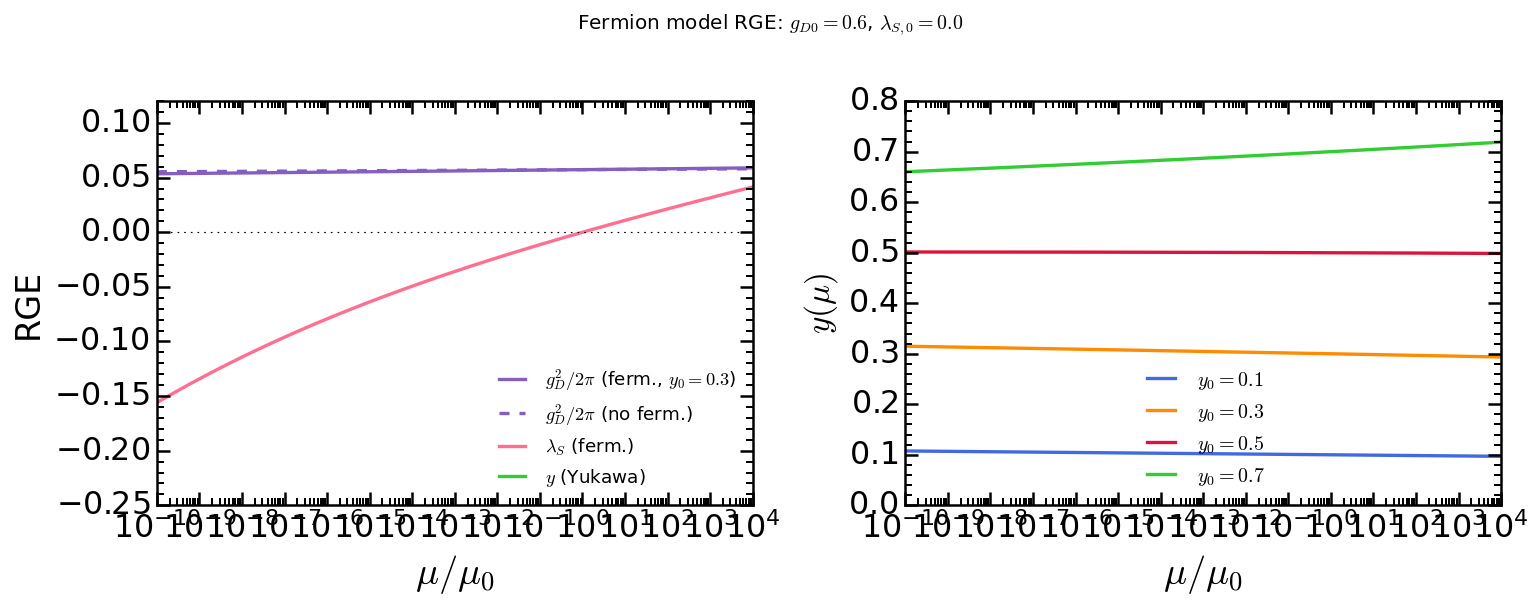

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)
fig.patch.set_facecolor('white')

# Left panel: coupling running (no fermion vs fermion)
# Reload no-fermion result from section 1
sol_nf = solve_ivp(
    rge_solver.RGEs_logMu,
    logT_span,
    [gD0**2, lambdaS0, ms0],
    dense_output=True, max_step=0.1,
)
gD2_nf = sol_nf.sol(logmu_vals)[0]

axes[0].plot(mu_vals, gD2_f  / (2*np.pi), lw=2, color='#845ec2',
             label=fr'$g_D^2/2\pi$ (ferm., $y_0={y0_f}$)')
axes[0].plot(mu_vals, gD2_nf / (2*np.pi), lw=2, color='#845ec2', ls='--',
             label=r'$g_D^2/2\pi$ (no ferm.)')
axes[0].plot(mu_vals, lambdaS_f,           lw=2, color='#ff6f91',
             label=r'$\lambda_S$ (ferm.)')
axes[0].plot(mu_vals, yukawa_f,            lw=2, color='limegreen',
             label=r'$y$ (Yukawa)')
axes[0].axhline(0, color='k', lw=0.7, ls=':')
ps.apply_standard_formatting(
    axes[0], xlog=True, ylog=False,
    xlabel=r'$\mu/\mu_0$', ylabel='RGE', ylim=(-0.25, 0.12),
)
axes[0].legend(loc='lower right', frameon=False, fontsize=11)

# Right panel: Yukawa running for several y0 values
y0_list = [0.1, 0.3, 0.5, 0.7]
colors  = ['royalblue', 'darkorange', 'crimson', 'limegreen']
for y0_i, c in zip(y0_list, colors):
    sol_i  = solve_ivp(
        rge_ferm_solver.RGEs_logMu,
        logT_span, [gD0_f**2, 0.0, 0.0, y0_i],
        dense_output=True, max_step=0.1,
    )
    y_i = sol_i.sol(logmu_vals)[3]
    axes[1].plot(mu_vals, y_i, lw=2, color=c, label=fr'$y_0={y0_i}$')
axes[1].axhline(0, color='k', lw=0.7, ls=':')
ps.apply_standard_formatting(
    axes[1], xlog=True, ylog=False,
    xlabel=r'$\mu/\mu_0$', ylabel=r'$y(\mu)$',
)
axes[1].legend(loc='best', frameon=False, fontsize=12)
plt.suptitle(fr'Fermion model RGE: $g_{{D0}}={gD0_f}$, $\lambda_{{S,0}}={lambdaS0_f}$',
             fontsize=12, y=1.01)
plt.tight_layout()

### 3.2 Scale dependence of the VEV (fermion model)

For each value of the initial coupling $g_D(\mu_0)$, run the fermion RGE to scale $\mu$ and minimize $V_{\rm eff}^{T=0}(\phi;\mu)$ to find the VEV $\langle\phi\rangle(\mu)$. Three panels show $y_0 = 0.1,\; 0.5,\; 1.0$; within each panel, curves correspond to $g_D(\mu_0) = 0.5, 0.6, 0.7, 0.8$. Dashed horizontals are the analytic Coleman–Weinberg limit $\langle\phi\rangle = e^{1/6}/g_D$.

In [23]:
mu0       = 1.0
ls0_f     = 0.0
gD0_list  = [0.5, 0.6, 0.7, 0.8]
y0_list   = [0.1, 0.5, 0.5]
mu_sweep  = np.logspace(-3, 3, 200)

# results_ferm[y0][gD0] = array of VEV/mu0 values
results_ferm = {}
for y0_val in y0_list:
    solver_ferm = bs_ht.BounceSolverHighT(
        veff=veff_ferm.VeffRGE_fermion(y0=y0_val)
    )
    results_ferm[y0_val] = {}
    for gD0 in gD0_list:
        v_vals = []
        for mu in mu_sweep:
            try:
                v_mu = solver_ferm.phi_min_Veff0(T=1, gD=gD0, scale=mu, ls0=ls0_f)
            except Exception:
                v_mu = np.nan
            v_vals.append(v_mu / mu0)
        results_ferm[y0_val][gD0] = np.array(v_vals)

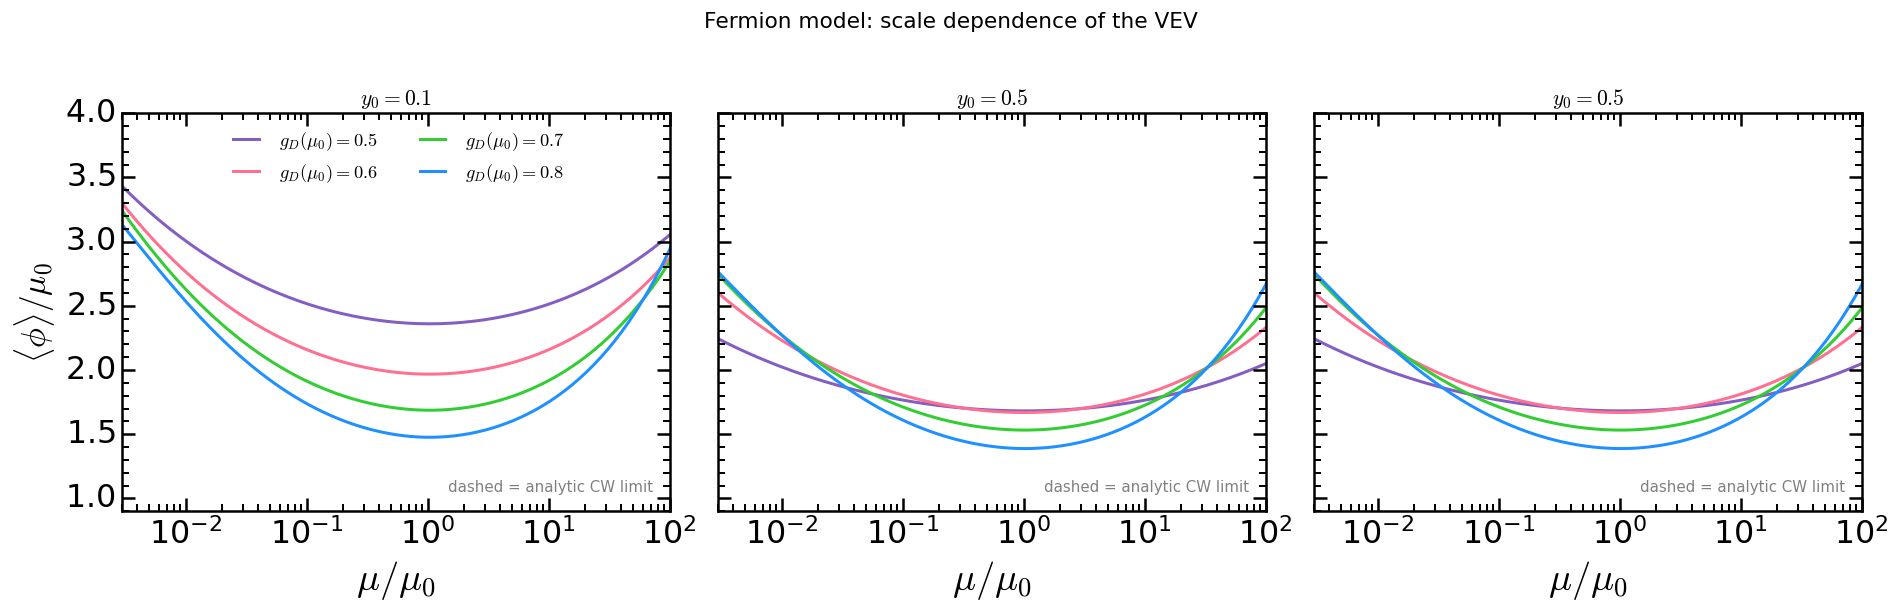

In [24]:
colors_gD = ['#845ec2', '#ff6f91', 'limegreen', 'dodgerblue']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=120, sharey=True)
fig.patch.set_facecolor('white')

for ax, y0_val in zip(axes, y0_list):
    for gD0, c in zip(gD0_list, colors_gD):
        v = results_ferm[y0_val][gD0]
        mask = np.isfinite(v) & (v > 0)
        ax.plot(mu_sweep[mask] / mu0, v[mask], lw=1.8, color=c,
                label=fr'$g_D(\mu_0)={gD0}$')
        # ax.axhline(np.exp(1/6) / gD0, color=c, ls='--', lw=1.0, alpha=0.7)

    ps.apply_standard_formatting(
        ax, xlog=True, ylog=False,
        xlabel=r'$\mu/\mu_0$',
        ylabel=r'$\langle\phi\rangle/\mu_0$' if ax is axes[0] else '',
        ylim=(0.9, 4), xlim=(3e-3, 1e2),
    )
    ax.set_title(fr'$y_0 = {y0_val}$', fontsize=13)
    ax.text(0.97, 0.05, 'dashed = analytic CW limit',
            transform=ax.transAxes, ha='right', fontsize=9, color='gray')

axes[0].legend(loc='upper center', frameon=False, fontsize=11, ncol=2)
plt.suptitle('Fermion model: scale dependence of the VEV', fontsize=13, y=1.02)
plt.tight_layout()